In [ ]:
# Numpy

In [1]:
import numpy as np

In [17]:
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])
print(a)
print(a.shape)
print(a.size)
print(a.dtype)

# slicing
# b = a[:3]
print(a[:3])

# Another way to access elements of the array[i,j]
print(a[1,2] == a[1][2])

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
(4, 3)
12
int64
[[1 2 3]
 [4 5 6]
 [7 8 9]]
True


In [22]:
print(np.zeros(2))
print(np.ones(3).dtype)
print(np.arange(5))

[0. 0.]
float64
[0 1 2 3 4]


In [27]:
data = np.arange(20)
print(data)
print(data.shape)
data = data.reshape(4, 5)
print(data)

print("Mean:", np.mean(data, axis=0))
print("Mean:", np.mean(data, axis=1))
print("Standard Deviation: ", np.std(data, axis=0))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
(20,)
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
Mean: [ 7.5  8.5  9.5 10.5 11.5]
Mean: [ 2.  7. 12. 17.]
Standard Deviation:  [5.59016994 5.59016994 5.59016994 5.59016994 5.59016994]


In [ ]:
# Pandas

In [63]:
import pandas as pd
df = pd.read_csv("StudentPerformance.csv")

In [31]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [32]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [64]:
# print(df.head())
# c_df = df
# c_df['Extracurricular Activities'] = c_df['Extracurricular Activities'].map({
#     'Yes': 1
# })
# print(df.head())
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})


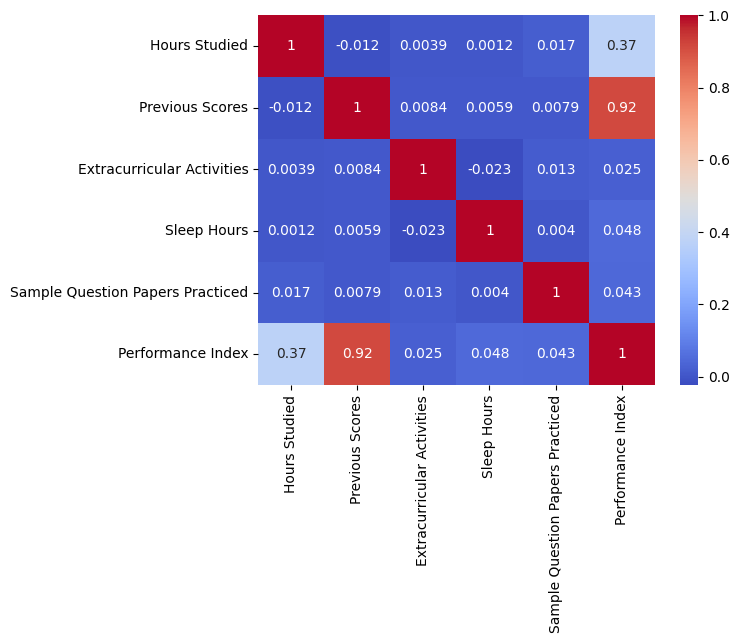

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


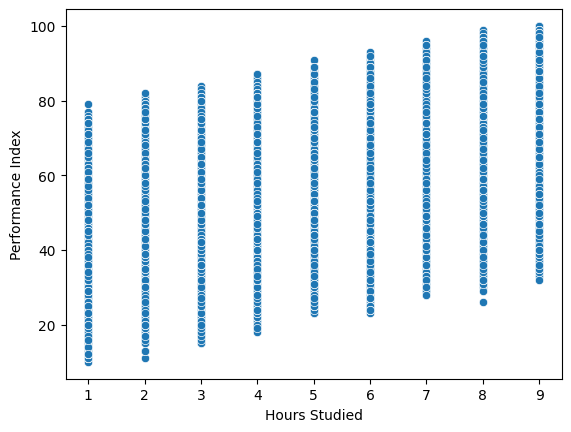

In [38]:
sns.scatterplot(
    x='Hours Studied',
    y='Performance Index',
    data=df
)
plt.show()


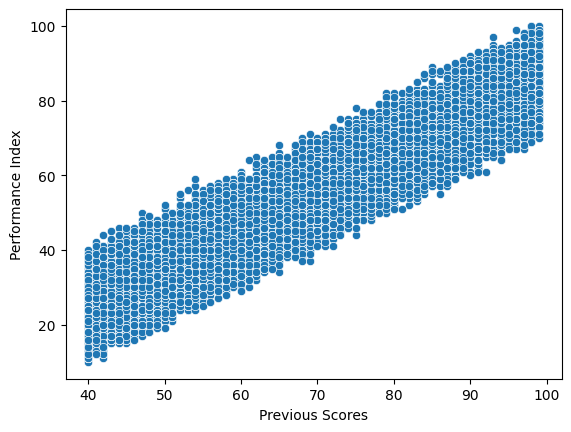

In [42]:
sns.scatterplot(
    x='Previous Scores',
    y='Performance Index',
    data=df
)
plt.show()


In [ ]:
# Linear Regression Model

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 4.082628398521853
R2 Score: 0.9889832909573145


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(X_train, y_train, epochs=30, verbose=0)

loss = model.evaluate(X_test, y_test)
print("Neural Network MSE:", loss)


/home/mtech/Documents/206125030/DS_AI/venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 4.1282
Neural Network MSE: 4.128201961517334
